# 📚 [LAB-10] 1. 신뢰구간

## 📘 #01. 신뢰구간 개요

표본에서 얻은 정보를 기반으로 모집단의 특성을 추정하는 방법 중 하나

신뢰구간은 주어진 신뢰수준(일반적으로 95% 또는 99% 등)에 따라 모수가 존재할 것으로 예상되는 범
위를 나타낸다. 예를 들어, 95% 신뢰구간은 모수가 95% 확률로 해당 구간에 속할 것으로 추정한다.

즉, 모수(모집단의 특성)에 대한 추정값의 범위를 제공하여 이를 통해 모평균의 신뢰성을 가늠하기 위해
서 사용한다.

신뢰구간은 일반적으로 표본 크기, 추정 방법, 데이터의 변동성 등과 같은 요소에 따라 달라질 수 있으며
정확한 신뢰구간을 구하기 위해서는 통계학적인 가정과 계산 방법을 사용해야 한다.

## 📘 #01. 준비작업

### 📝 [1] 패키지 참조

In [1]:
from hossam import load_data
from scipy.stats import t
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
from math import sqrt

### 📝 [2] 그래프 초기화

In [3]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

### 📝 [3] 데이터 가져오기

In [4]:
origin = load_data("height")
origin

[data] https://data.hossam.kr/data/lab10/height.xlsx
[desc] 어느 학교의 학년, 성별, 키에 대한 가상의 조사 자료 (출처: 방송통신대학교 통계학개론)
[!] Cannot read metadata


,학년,성별,키
0,1,남자,163
1,2,여자,154
2,1,남자,171
3,3,여자,160
4,4,남자,169
5,4,남자,175
6,2,남자,179
7,1,여자,166
8,1,남자,169
9,1,남자,164


## 신뢰구간 구하기

### 📝 [1] 신뢰구간을 구하는데 필요한 값 산출

In [5]:
clevel = 0.95
data = origin['키']

In [6]:
n = len(data)
n

36

In [7]:
dof = n-1
dof

35

In [10]:
sample_mean = data.mean()
sample_mean

np.float64(167.83333333333334)

In [12]:
sample_std = data.std()
sample_std


np.float64(7.315345905306578)

In [13]:
sample_std_error = sample_std / sqrt(n)
sample_std_error

np.float64(1.2192243175510964)

### 📝 [2] 신뢰구간

In [14]:
cmin,cmax = t.interval(clevel,dof,loc=sample_mean,scale=sample_std_error)
cmin,cmax

(np.float64(165.35817637995726), np.float64(170.30849028670943))

/var/folders/q0/gfh2kgjd38q9q1jlkn069tmr0000gn/T/ipykernel_9411/3976560321.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.kdeplot(data=data, fill=False, alpha=0.5, palette="pastel")


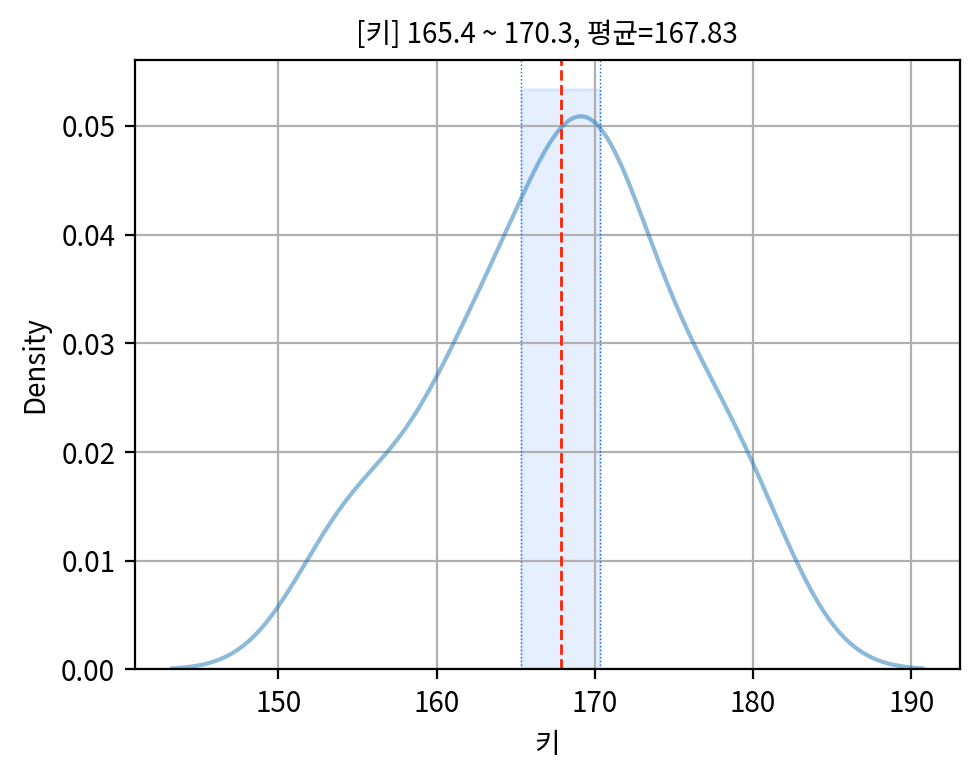

In [19]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

#2) 그래프 그리기 -> seaborn 사용
sb.kdeplot(data=data, fill=False, alpha=0.5, palette="pastel")

# 신뢰구간 범위 그리기 (cmin ~ cmax)
ax.axvline(cmin, linestyle=':', color='#0066ff', linewidth=0.5)
ax.axvline(cmax, linestyle=':', color='#0066ff', linewidth=0.5)

# 현재 축 범위 가져오기
ymin, ymax = ax.get_ylim()
ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1, color='#0066ff88')

# 평균 표시
ax.axvline(sample_mean, linestyle='--', linewidth=1, color='#ff2200')

#3) 그래프 꾸미기
ax.grid(True)
ax.set_title(f"[{data.name}] {cmin:.1f} ~ {cmax:.1f}, 평균={sample_mean:0.2f}", fontsize=10)


plt.tight_layout()
#plt.savefig("myplot.png", dpi=my_dpi)
plt.show() # 그래프 화면 출력
plt.close()